# GeoBrain Bayesian Seismic Inversion with SVGD

Bayesian seismic inversion for porosity and clay volume estimation using
Stein Variational Gradient Descent (SVGD) in a latent space defined by
a convolutional autoencoder.

---

This example performs **Bayesian seismic inversion in a learned latent
space** using SVGD.  A pre-trained convolutional autoencoder compresses
the model space, enabling efficient posterior sampling in low dimensions.

```
Encode prior samples -> Run SVGD in latent space -> Decode posterior samples
```

Outputs: porosity and clay-volume posterior mean, standard deviation, and
individual realisations.

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from geobrain.core import InverseProblem
from geobrain.bayes import SVGD

## Configuration

In [2]:
RANDOM_SEED = 2025
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("Example 10: SVGD Bayesian Seismic Inversion")
print("=" * 60)
print(f"Device: {DEVICE}")

Example 10: SVGD Bayesian Seismic Inversion
Device: cpu


## Rock-Physics Constants

Quartz and clay elastic moduli, fluid properties, and Hertz–Mindlin contact
parameters.  These are fixed throughout the inversion.

In [3]:
PHI_MAX = 0.35
VSH_MAX = 1.0
RHOB_QTZ = 2.65
RHOB_CLY = 2.62
KW = 2.5
RHOB_W = 1.03
KG = 0.8
RHOB_G = 0.8
CRITPORO = 0.4
COORDNUM = 7

## Convolutional Autoencoder

The architecture **must match the pre-trained weights exactly**:

| Component | Layers | Output |
|-----------|--------|--------|
| **Encoder** | 4 × Conv2d + Tanh | 64-channel latent representation |
| **Decoder** | 4 × ConvTranspose2d + ClippedLinear [0, 1] | 2-channel (porosity, clay) output |

`ClippedLinearActivation` clamps the output to [0, 1].

In [4]:
class ClippedLinearActivation(nn.Module):
    def forward(self, x):
        return torch.clamp(x, 0.0, 1.0)


class ConvAutoencoder2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(2, 8, 3, stride=2, padding=1),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=2, output_padding=1),
            nn.ConvTranspose2d(16, 8, 4, stride=2, padding=2, output_padding=1),
            nn.ConvTranspose2d(8, 2, 4, stride=2, padding=2, output_padding=1),
            ClippedLinearActivation()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

## Seismic Forward Model

A custom forward chain:

1. Decode latent vector → porosity and clay volume
2. VRH mineral mixing → **Stiff Sand** dry frame → Gassmann saturation
3. Compute P-wave impedance and normal-incidence reflectivity
4. Wavelet convolution → synthetic seismic

> **Note**: This example uses the *Stiff Sand* model (not Soft Sand),
> appropriate for more cemented rocks.

In [5]:
class SeismicForwardModel:
    def __init__(self, decoder, latent_dim, bulk_moduli, shear_moduli,
                 wavelet, pressure, device):
        self.decoder = decoder
        self.latent_dim = latent_dim
        self.bulk_moduli = bulk_moduli
        self.shear_moduli = shear_moduli
        self.wavelet = wavelet
        self.pressure = pressure
        self.device = device
        self.rhominc = torch.tensor([RHOB_QTZ, RHOB_CLY], device=device)
        self.kflc = torch.tensor([KW, KG], device=device)
        self.rhoflc = torch.tensor([RHOB_W, RHOB_G], device=device)

    def __call__(self, x):
        z = x.reshape(-1, *self.latent_dim)
        model = self.decoder(z)
        porosity = PHI_MAX * model[:, 0] + 0.001
        clay = model[:, 1]
        sw = torch.ones_like(porosity)
        mineral_volumes = torch.stack([1 - clay, clay], dim=1)
        fluid_saturations = torch.stack([sw, 1 - sw], dim=1)
        matrix_bulk = self._vrh_average(mineral_volumes, self.bulk_moduli)
        matrix_shear = self._vrh_average(mineral_volumes, self.shear_moduli)
        matrix_density = torch.sum(mineral_volumes * self.rhominc[:, None, None], dim=1)
        fluid_bulk = 1.0 / (fluid_saturations[:, 0] / self.kflc[0] +
                            fluid_saturations[:, 1] / self.kflc[1])
        fluid_density = torch.sum(fluid_saturations * self.rhoflc[:, None, None], dim=1)
        bulk_density = (1 - porosity) * matrix_density + porosity * fluid_density
        dry_bulk, dry_shear = self._stiff_sand(matrix_bulk, matrix_shear, porosity)
        sat_bulk = dry_bulk + ((1 - dry_bulk / matrix_bulk) ** 2 /
                               (porosity / fluid_bulk + (1 - porosity) / matrix_bulk -
                                dry_bulk / matrix_bulk ** 2))
        sat_shear = dry_shear
        M = sat_bulk + 4/3 * sat_shear
        vp = torch.sqrt(torch.clamp(M / bulk_density, min=1e-10))
        impedance = vp * bulk_density
        reflectivity = ((impedance[:, 1:] - impedance[:, :-1]) /
                        (impedance[:, 1:] + impedance[:, :-1]))
        seismic = torch.einsum('nij,ik->njk', reflectivity, self.wavelet)
        return seismic.reshape(seismic.shape[0], -1)

    def _vrh_average(self, volumes, moduli):
        voigt = torch.sum(volumes * moduli, dim=1)
        reuss = 1.0 / torch.sum(volumes / moduli, dim=1)
        return 0.5 * (voigt + reuss)

    def _stiff_sand(self, k_matrix, g_matrix, porosity):
        poisson = (3 * k_matrix - 2 * g_matrix) / (6 * k_matrix + 2 * g_matrix)
        p_eff = self.pressure.unsqueeze(0)
        k_hm = ((COORDNUM ** 2 * (1 - CRITPORO) ** 2 * g_matrix ** 2 * p_eff) /
                (18 * np.pi ** 2 * (1 - poisson) ** 2)) ** (1/3)
        g_hm = ((5 - 4 * poisson) / (5 * (2 - poisson)) *
                (3 * COORDNUM ** 2 * (1 - CRITPORO) ** 2 * g_matrix ** 2 * p_eff) /
                (2 * np.pi ** 2 * (1 - poisson) ** 2)) ** (1/3)
        z = g_hm / 6 * (9 * k_hm + 8 * g_hm) / (k_hm + 2 * g_hm)
        phi_ratio = (porosity / CRITPORO)
        k_dry = 1.0 / (phi_ratio / (k_hm + 4/3 * g_hm) +
                       (1 - phi_ratio) / (k_matrix + 4/3 * g_hm)) - 4/3 * g_hm
        g_dry = 1.0 / (phi_ratio / (g_hm + z) +
                       (1 - phi_ratio) / (g_matrix + z)) - z
        return k_dry, g_dry

## Prior

In [6]:
def log_prior(theta):
    return -0.5 * torch.sum(theta ** 2, dim=1)

## Load Data

| File | Content |
|------|---------|
| `seismic.npy` | Observed seismic data |
| `prior_poros.npy` / `prior_vshs.npy` | Prior model realisations |
| `Modulus.mat` | Spatially varying mineral moduli |
| `wavelet.npy` | Source wavelet |
| `pretrained_model.pth` | Autoencoder weights |

In [7]:
def load_seismic_data(data_dir, slice_index):
    seismic = np.load(os.path.join(data_dir, 'seismic.npy'))
    prior_porosity = np.load(os.path.join(data_dir, 'prior_poros.npy'))
    prior_clay = np.load(os.path.join(data_dir, 'prior_vshs.npy'))
    moduli = sio.loadmat(os.path.join(data_dir, 'Modulus.mat'))
    Kqtz = moduli['Kqtz'][:, :, slice_index]
    Gqtz = moduli['Gqtz'][:, :, slice_index]
    Kcly = moduli['Kcly'][:, :, slice_index]
    Gcly = moduli['Gcly'][:, :, slice_index]
    norm_phi = prior_porosity.transpose(2, 0, 1) / PHI_MAX
    clay_vol = prior_clay.transpose(2, 0, 1)
    prior_model = np.stack([norm_phi, clay_vol], axis=1).astype(np.float32)
    seismic_obs = torch.tensor(seismic[1:, :, slice_index].T).reshape(1, -1)
    mineral_bulk = torch.tensor(np.array([Kqtz, Kcly]))
    mineral_shear = torch.tensor(np.array([Gqtz, Gcly]))
    return seismic_obs, prior_model, mineral_bulk, mineral_shear

## SVGD Inversion Workflow

| Step | Action |
|------|--------|
| 1 | Load seismic data and prior models |
| 2 | Load pre-trained autoencoder |
| 3 | Encode prior samples → initial particles in latent space |
| 4 | Build posterior via `InverseProblem.as_posterior()` |
| 5 | Run SVGD: 100 particles, 50 iterations |
| 6 | Decode final particles → porosity & clay posterior |

In [8]:
DATA_DIR = '../data/svgd'
SLICE_IDX = 20
N_PARTICLES = 100
N_STEPS = 50
LR = 0.1

# ---- Step 1: Load data ----

print("\n--- Step 1: Load Data ---")

seismic_obs, prior_model, bulk_moduli, shear_moduli = load_seismic_data(
    DATA_DIR, SLICE_IDX)
seismic_obs = seismic_obs.to(DEVICE)
bulk_moduli = bulk_moduli.to(DEVICE)
shear_moduli = shear_moduli.to(DEVICE)

wavelet = np.load(os.path.join(DATA_DIR, 'wavelet.npy'))
wavelet = torch.tensor(wavelet, dtype=torch.float32, device=DEVICE)

twt = np.arange(0.7, 1.1, 0.002).astype(np.float32)
pressure = torch.tensor(0.0305 * twt, device=DEVICE)

print(f"  Seismic shape: {seismic_obs.shape}")
print(f"  Prior models: {prior_model.shape}")

# ---- Step 2: Load autoencoder (pretrained weights) ----

print("\n--- Step 2: Load Autoencoder ---")

autoencoder = ConvAutoencoder2D().to(DEVICE)
autoencoder.load_state_dict(
    torch.load(os.path.join(DATA_DIR, 'pretrained_model.pth'),
               map_location=DEVICE))
autoencoder.eval()

latent_dim = [64, 13, 13]
latent_size = int(np.prod(latent_dim))
print(f"  Latent dimension: {latent_dim} ({latent_size} total)")

# ---- Step 3: Initialize particles in latent space ----

print("\n--- Step 3: Initialize Particles ---")

initial_model = torch.tensor(prior_model[:N_PARTICLES], device=DEVICE)
with torch.no_grad():
    latent_init = autoencoder.encoder(initial_model).reshape(N_PARTICLES, -1)

print(f"  Number of particles: {N_PARTICLES}")
print(f"  Initial latent shape: {latent_init.shape}")

# ---- Step 4: Build forward model and posterior ----

print("\n--- Step 4: Build Posterior ---")

forward_model = SeismicForwardModel(
    autoencoder.decoder, latent_dim, bulk_moduli, shear_moduli,
    wavelet, pressure, DEVICE)

# Create inverse problem and posterior
problem = InverseProblem(
    forward_fn=forward_model,
    observed=seismic_obs,
    noise_std=10.0,
)

posterior = problem.as_posterior(log_prior=log_prior, dim=latent_size)

# ---- Step 5: Run SVGD ----

print("\n--- Step 5: Run SVGD ---")

svgd = SVGD(target=posterior, lr=LR, optimizer='adagrad', device=DEVICE)
result = svgd.run(
    n_samples=N_PARTICLES,
    n_steps=N_STEPS,
    initial_samples=latent_init,
    verbose=True,
    print_every=10,
    patience=20,
    min_delta=1e-4,
    return_trajectory=True,
    trajectory_every=10,
)

# ---- Step 6: Decode posterior samples ----

print("\n--- Step 6: Decode Posterior Samples ---")

final_samples = result.samples

with torch.no_grad():
    particles = final_samples.reshape(-1, *latent_dim)
    decoded_models = autoencoder.decoder(particles).cpu().numpy()

phi_mean = np.mean(decoded_models[:, 0], axis=0) * PHI_MAX
phi_std = np.std(decoded_models[:, 0], axis=0) * PHI_MAX
clay_mean = np.mean(decoded_models[:, 1], axis=0)
clay_std = np.std(decoded_models[:, 1], axis=0)

print("\n" + "=" * 60)
print("INVERSION SUMMARY")
print("=" * 60)
print(result.summary())
print(f"\nPosterior Statistics:")
print(f"  Mean porosity: {phi_mean.mean():.3f} +/- {phi_std.mean():.3f}")
print(f"  Mean clay volume: {clay_mean.mean():.3f} +/- {clay_std.mean():.3f}")

results = {
    'result': result,
    'decoded_models': decoded_models,
    'phi_mean': phi_mean, 'phi_std': phi_std,
    'clay_mean': clay_mean, 'clay_std': clay_std,
    'prior_model': prior_model[:N_PARTICLES],
}


--- Step 1: Load Data ---
  Seismic shape: torch.Size([1, 40200])
  Prior models: (500, 2, 201, 201)

--- Step 2: Load Autoencoder ---
  Latent dimension: [64, 13, 13] (10816 total)

--- Step 3: Initialize Particles ---
  Number of particles: 100
  Initial latent shape: torch.Size([100, 10816])

--- Step 4: Build Posterior ---

--- Step 5: Run SVGD ---

--- Step 6: Decode Posterior Samples ---

INVERSION SUMMARY
Sampling Result: SVGD
Samples: 100 x 10816
Steps: 50
Converged: False
Final log prob: -1.282550e+06
Time: 66.00s

Posterior Statistics:
  Mean porosity: 0.152 +/- 0.039
  Mean clay volume: 0.377 +/- 0.174


## Convergence

Log-posterior vs. iteration number.

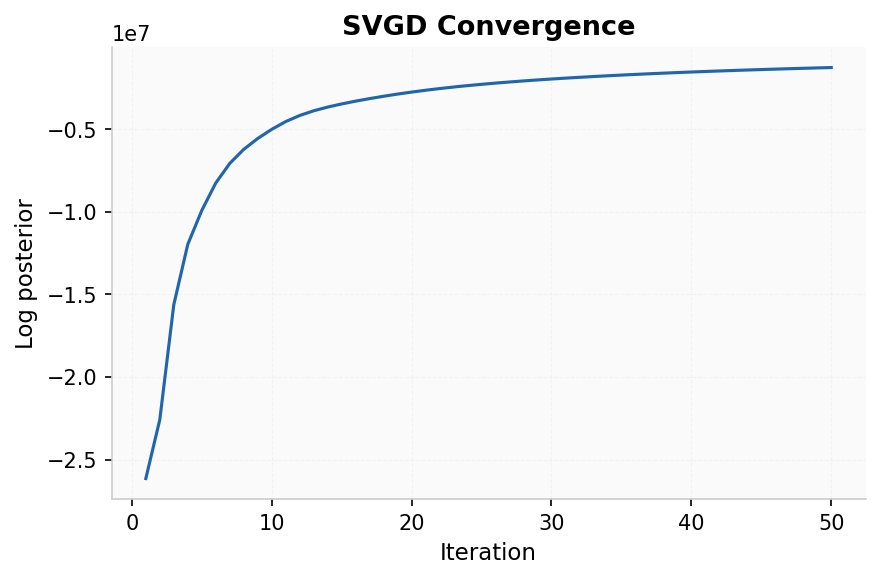

In [9]:
result = results['result']

fig, ax = plt.subplots(figsize=(6, 4))
iters = np.arange(1, len(result.log_prob_history) + 1)
ax.plot(iters, result.log_prob_history, color="#2166ac", lw=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Log posterior")
ax.set_title("SVGD Convergence")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "14_convergence.png"))
plt.show()

## Posterior Statistics

2 x 2 panel: posterior mean and standard deviation for both porosity and
clay volume. The std maps highlight where the data constrains the model
well (low std) and where uncertainty remains (high std).

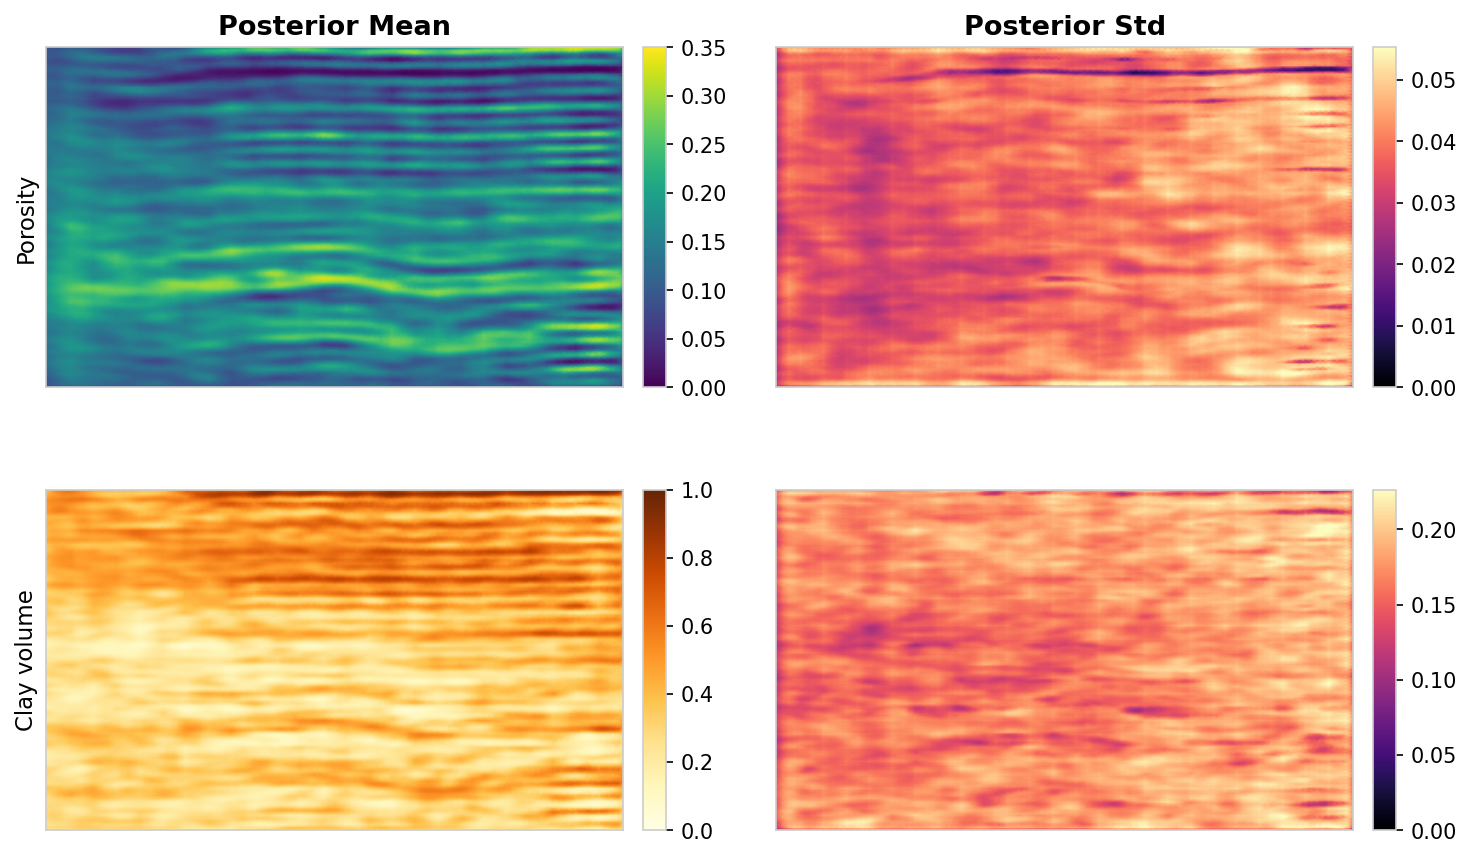

In [10]:
phi_mean  = results['phi_mean']
phi_std   = results['phi_std']
clay_mean = results['clay_mean']
clay_std  = results['clay_std']

rows = [
    ("Porosity",    phi_mean,  phi_std,  "viridis", 0.0, PHI_MAX, "magma"),
    ("Clay volume", clay_mean, clay_std, "YlOrBr",  0.0, 1.0,    "magma"),
]

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(
    2, 5,
    width_ratios=[1, 0.04, 0.12, 1, 0.04],
    hspace=0.30, wspace=0.08,
    left=0.06, right=0.96, bottom=0.05, top=0.92,
)

col_titles = ["Posterior Mean", "Posterior Std"]

for r, (label, mean, std, cm_m, vmin, vmax, cm_s) in enumerate(rows):
    q25, q75 = np.percentile(std, [25, 75])
    s_vmax = q75 + 1.5 * (q75 - q25)
    s_vmax = max(s_vmax, np.percentile(std, 75))

    ax = fig.add_subplot(gs[r, 0])
    im_m = ax.imshow(mean, origin="upper",
                     vmin=vmin, vmax=vmax,
                     aspect="auto", cmap=cm_m, interpolation="bilinear")
    if r == 0:
        ax.set_title(col_titles[0], fontweight="semibold", pad=6)
    ax.set_ylabel(label, labelpad=4)
    ax.set_xticks([])
    ax.set_yticks([])

    cax = fig.add_subplot(gs[r, 1])
    fig.colorbar(im_m, cax=cax)

    ax = fig.add_subplot(gs[r, 3])
    im_s = ax.imshow(std, origin="upper",
                     vmin=0, vmax=s_vmax,
                     aspect="auto", cmap=cm_s, interpolation="bilinear")
    if r == 0:
        ax.set_title(col_titles[1], fontweight="semibold", pad=6)
    ax.set_xticks([])
    ax.set_yticks([])

    cax = fig.add_subplot(gs[r, 4])
    fig.colorbar(im_s, cax=cax)

plt.savefig(os.path.join(FIGS_DIR, "14_posterior_stats.png"))
plt.show()

## Prior vs. Posterior Realisations

Side-by-side comparison of individual prior and posterior porosity samples.
The posterior realisations should be more consistent with each other and
better constrained by the seismic data.

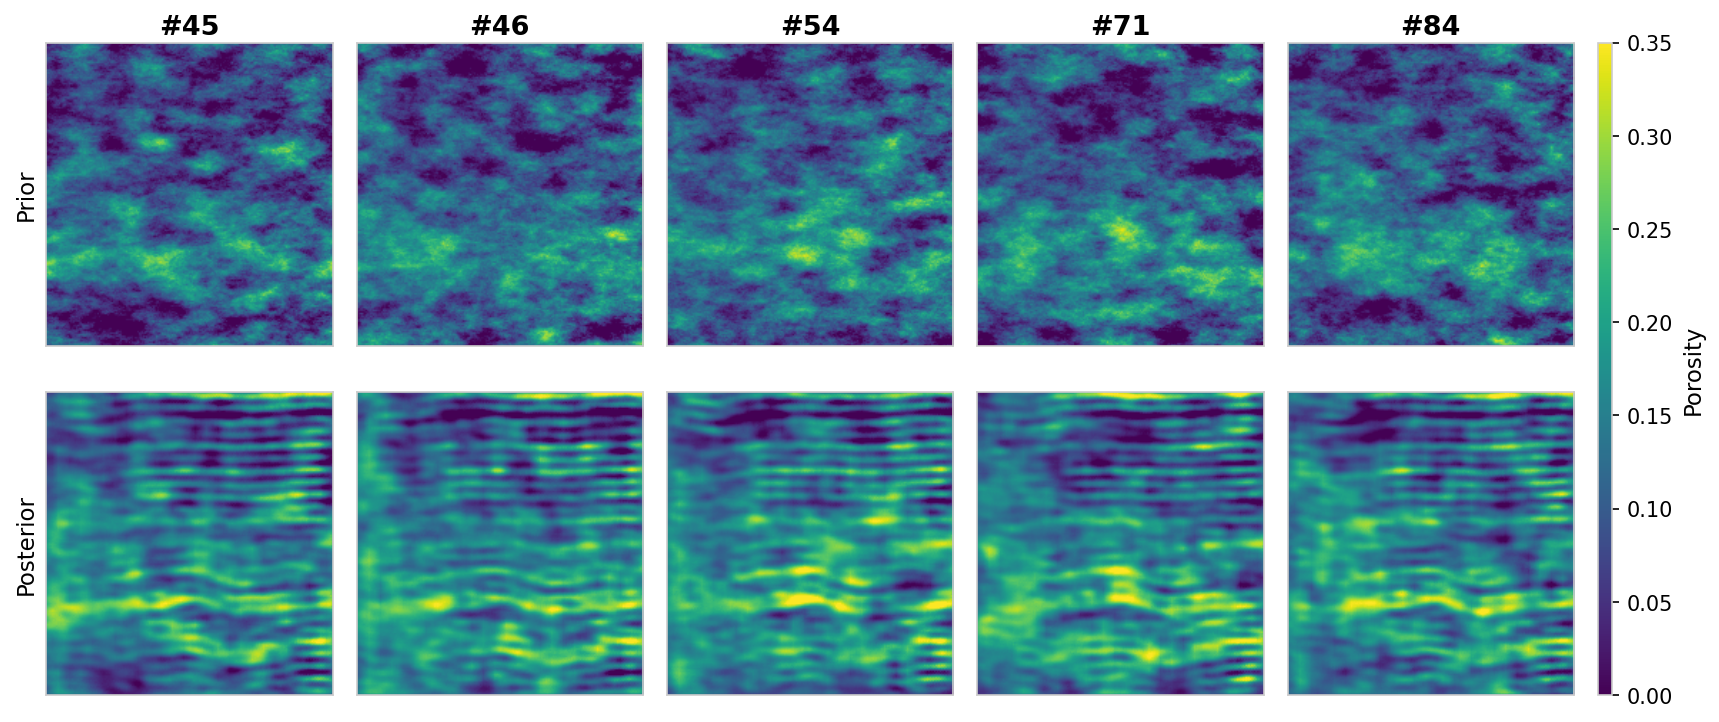

In [11]:
decoded = results['decoded_models']   # [N, 2, H, W]
prior   = results['prior_model']      # [N, 2, H, W]
n_samples = 5
n_total = decoded.shape[0]

np.random.seed(42)
indices = np.sort(np.random.choice(n_total, n_samples, replace=False))

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(
    2, n_samples + 1,
    width_ratios=[1] * n_samples + [0.05],
    hspace=0.15, wspace=0.10,
    left=0.06, right=0.93, bottom=0.05, top=0.92,
)

row_labels = ["Prior", "Posterior"]
im = None

for r in range(2):
    for c, idx in enumerate(indices):
        ax = fig.add_subplot(gs[r, c])
        if r == 0:
            img = prior[idx, 0] * PHI_MAX
        else:
            img = decoded[idx, 0] * PHI_MAX
        im = ax.imshow(img, origin="upper",
                       vmin=0, vmax=PHI_MAX,
                       aspect="auto", cmap="viridis",
                       interpolation="bilinear")
        if r == 0:
            ax.set_title(f"#{idx+1}", fontweight="semibold", pad=4)
        if c == 0:
            ax.set_ylabel(row_labels[r], labelpad=4)
        ax.set_xticks([])
        ax.set_yticks([])

cax = fig.add_subplot(gs[:, n_samples])
cb = fig.colorbar(im, cax=cax)
cb.set_label("Porosity")

plt.savefig(os.path.join(FIGS_DIR, "14_realizations.png"))
plt.show()